# 🚀 XGBoost (Extreme Gradient Boosting)

> **Принципі (Boosting):** "Қателерден сабақ алу". Модельдер (ағаштар) тізбекті түрде құрылады. Әрбір келесі модель алдыңғы модельдің қателеріне көбірек көңіл бөліп, жалпы қатені азайтуға бағытталады.

---

## ⚙️ Негізгі Гиперпараметрлер (xgboost.XGBClassifier)

XGBoost артық үйренуге (overfitting) өте бейім, сондықтан мына параметрлерді дұрыс баптау маңызды:

| Параметр | Түсіндірмесі | Баптау кеңесі |
| :--- | :--- | :--- |
| `learning_rate` (немесе `eta`) | Әр ағаштың қосатын үлесі (қадам жылдамдығы). | `0.01` мен `0.3` аралығында болады. Мән кіші болған сайын, `n_estimators` санын көбейту керек. |
| `n_estimators` | Құрылатын ағаштардың жалпы саны. | `100`-ден бастап, `1000`-ге дейін көтеруге болады (бірақ `learning_rate`-пен бірге реттеңіз). |
| `max_depth` | Ағаштың максималды тереңдігі. | Overfitting-тің алдын алу үшін `3`, `5` немесе `7` сияқты кіші мәндер қолданылады. |
| `subsample` | Әр ағашты жаттықтыруға алынатын деректер үлесі. | `0.8` (деректердің 80%-ы) жиі қолданылады. Модельді жалпылауға (generalization) көмектеседі. |
| `colsample_bytree` | Әр ағашқа берілетін бағандар (features) үлесі. | `0.8` мәні жақсы жұмыс істейді. Random Forest-тегі `max_features` сияқты. |

---

## 💻 Жылдам Бастау (Quick Start)

```python
# Кітапхананы орнату (егер жоқ болса): !pip install xgboost
import xgboost as xgb
from sklearn.metrics import accuracy_score

# 1. Модельді инициализациялау
xgb_model = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    max_depth=5,
    random_state=42,
    eval_metric='logloss' # Ескертулер шықпас үшін
)

# 2. Модельді жаттықтыру
xgb_model.fit(X_train, y_train)

# 3. Болжам жасау
predictions = xgb_model.predict(X_test)
print(f"XGBoost Дәлдігі: {accuracy_score(y_test, predictions):.2f}")

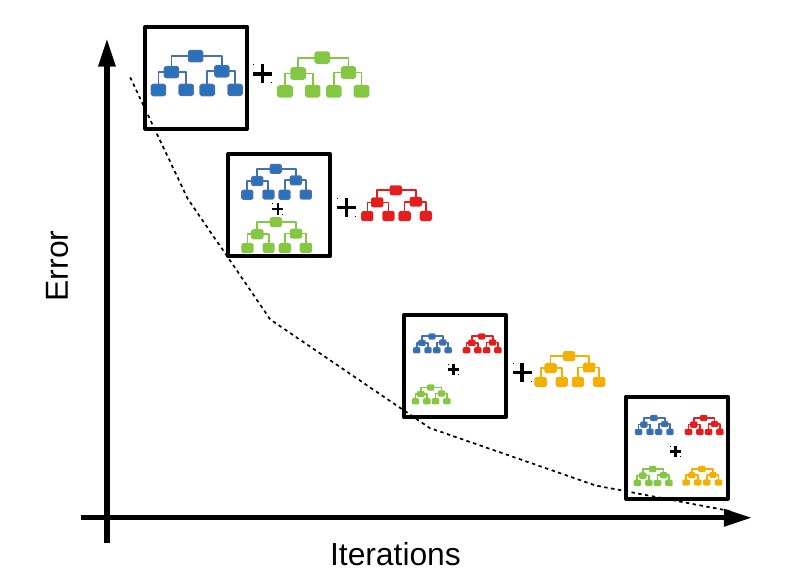

In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


In [5]:
# 1. Деректерді жүктеу (Титаник)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# 2. Қарапайым деректерді дайындау (Data Preprocessing)
# Жынысты 0 және 1-ге айналдыру
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [7]:
# Жас пен Билет құнындағы бос орындарды медианамен толтыру
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())

In [8]:
# Қажетті бағандарды таңдау
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']


In [9]:
# 3. Жаттығу және тест жиынтықтарына бөлу
# XGBoost валидация жасау үшін тест жиынтығын қолданады
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
# 4. XGBoost моделін баптау (early_stopping_rounds осында қосылады)
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=10
)

In [11]:
# 5. Модельді жаттықтыру
print("XGBoost жаттығу процесі басталуда...\n")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # Әр 50 қадам сайын нәтижені экранға шығарады
)

XGBoost жаттығу процесі басталуда...

[0]	validation_0-logloss:0.65826
[50]	validation_0-logloss:0.43223
[62]	validation_0-logloss:0.43359


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [12]:
# 6. Нәтижені тексеру
print("\n--- НӘТИЖЕ ---")
predictions = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"XGBoost Дәлдігі (Accuracy): {accuracy * 100:.2f}%")
print(f"Ең жақсы нәтиже көрсеткен ағаш саны: {xgb_model.best_iteration}")


--- НӘТИЖЕ ---
XGBoost Дәлдігі (Accuracy): 81.56%
Ең жақсы нәтиже көрсеткен ағаш саны: 52
